# XGBoost i LightGBM - Predikcija PM2.5

---

Ovaj notebook prikazuje kompletan analitički tok za dva modela zasnovana na **gradijentnom bustingu**: XGBoost i LightGBM koji su implementirani kao deo modula 1 u okviru projekta predikcije kvaliteta vazduha.

Oba modela rešavaju isti regresioni zadatak: na osnovu izmerenih vrednosti zagađujućih materija i vremenskih obeležja iz prethodnih 48 sati, predvideti **koncentraciju PM2.5 čestica 24 sata unapred**.

Gradijentni busting algoritmi su u praksi jedan od najjačih pristupa za tabelarne podatke sa mnogo feature-a. Umesto jednog složenog modela, trenira se veliki broj jednostavnih stabala odlučivanja, svako naredno stablo fokusira se isključivo na greške koje je prethodno napravilo i pokušava da ih ispravi. XGBoost i LightGBM rade po istom principu, ali se razlikuju u načinu rasta stabala, što utiče na brzinu treninga i ponašanje na velikim skupovima podataka.

**Struktura notebooka:**
1. Uvoz biblioteka i učitavanje istreniranih modela
2. Priprema podataka i generisanje predikcija na test skupu
3. Evaluacija: RMSE, MAE, R²
4. Grafička analiza: vremenska serija, scatter plot
5. Važnost feature-a (interpretabilnost modela)
6. AQI kategorije
7. Zaključak

## 1. Uvoz biblioteka i učitavanje modela

Uvozimo sve potrebne biblioteke za numeričku obradu, vizualizaciju i učitavanje modela. Modeli su prethodno istrenirani skriptom `main.py` i sačuvani na disk u formatu `.pkl` pomoću biblioteke `joblib`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import joblib

from src.data_prep import prepare_city_data
from src.split import time_series_split, get_X_y
from src.evaluate import evaluate_predictions
from src.models.xgboost_model import get_xgb_feature_columns, predict_xgb
from src.models.lightgbm_model import get_lgbm_feature_columns, predict_lgbm
from src.visualize import (
    print_metrics_table, plot_metrics_comparison, plot_timeseries,
    plot_scatter_comparison, plot_feature_importance, plot_aqi_distribution,
)

CITY = 'Beograd'
CSV_PATH = f'../data/raw/{CITY.lower()}.csv'
RESULTS = '../results'

print('Biblioteke uspešno učitane.')

Biblioteke uspešno učitane.


Učitavamo istrenirane modele sa diska. Oba modela su trenirana na podacima za Beograd od 2016. do 2023. godine i čuvana u formatu `.pkl`.

In [2]:
xgb_model  = joblib.load(f'{RESULTS}/xgboost/xgboost_model_{CITY}.pkl')
lgbm_model = joblib.load(f'{RESULTS}/lightgbm/lightgbm_model_{CITY}.pkl')

print(f'XGBoost model učitan  - {type(xgb_model).__name__}')
print(f'LightGBM model učitan - {type(lgbm_model).__name__}')

XGBoost model učitan  — XGBRegressor
LightGBM model učitan — LGBMRegressor


## 2. Priprema podataka i predikcija na test skupu

Podaci su podeljeni **hronološki** bez ikakvog mešanja redosleda. Ovo je ključno za vremenske serije jer nasumično mešanje bi dovelo do **curenja podataka iz budućnosti u prošlost**. Model bi tokom treninga video podatke koji dolaze posle onih na kojima se testira, što bi dalo lažno optimistične rezultate.

| Skup | Period | Udeo | Namena |
|------|--------|------|--------|
| Train | jun 2016 → jun 2023 | 70% | Model uči na ovim podacima |
| Validacioni | jun 2023 → jun 2025 | 20% | Early stopping, zaustavljanje kada model počne da se preprilagođava |
| Test | jun 2025 → jun 2026 | 10% | Finalna ocena, model ovo vidi **samo jednom** |

Svaki model koristi skup od **40 feature-a**: sirove vrednosti 6 polutanata, 4 vremenska obeležja (sat, mesec, dan u nedelji, grejana sezona), lag vrednosti PM2.5 i PM10 za odabrane sate unazad, i rolling statistike (prosek, standardna devijacija, maksimum) za prozore od 12h i 24h.

In [3]:
df = prepare_city_data(CSV_PATH, city_name=CITY)
train_df, val_df, test_df = time_series_split(df)

feature_cols_xgb  = get_xgb_feature_columns()
feature_cols_lgbm = get_lgbm_feature_columns()

X_test_xgb,  y_test = get_X_y(test_df, feature_cols_xgb)
X_test_lgbm, _      = get_X_y(test_df, feature_cols_lgbm)

# Predikcije — np.maximum osigurava da PM2.5 ne može biti negativno
y_pred_xgb  = np.maximum(predict_xgb(xgb_model,   X_test_xgb),  0)
y_pred_lgbm = np.maximum(predict_lgbm(lgbm_model, X_test_lgbm), 0)

print(f'Test skup: {len(y_test):,} sati ({test_df["date"].min().date()} → {test_df["date"].max().date()})')
print(f'Broj feature-a: {len(feature_cols_xgb)}')
print(f'Predikcije generisane.')

Test skup: 8,856 sati (2025-06-01 → 2026-06-04)
Broj feature-a: 40
Predikcije generisane.


## 3. Evaluacija: RMSE, MAE, R²

Modele ocenjujemo na test skupu koji nijedan od njih nije video tokom treninga. Koristimo tri metrike:

- **RMSE** *(Root Mean Squared Error)* - primarna metrika. Greške se kvadriraju pre usrednjavanja, što znači da model koji napravi nekoliko velikih promašaja (npr. ne predvidi zimski skok zagađenja) biva drastično kažnjen. Izražen je u μg/m³.
- **MAE** *(Mean Absolute Error)* - prosečna apsolutna greška u μg/m³. Intuitivno: u proseku, za koliko μg/m³ se model razlikuje od stvarne vrednosti.
- **R²** *(Koeficijent determinacije)* - vrednost između 0 i 1 koja govori koliki procenat varijacije PM2.5 model uspeva da objasni. R²=1 bi značilo savršenu predikciju.

In [4]:
result_xgb  = evaluate_predictions(y_test, y_pred_xgb,  model_name='XGBoost')
result_lgbm = evaluate_predictions(y_test, y_pred_lgbm, model_name='LightGBM')

results_df = print_metrics_table([result_xgb, result_lgbm])

=== Rezultati na test skupu ===
             RMSE     MAE      R2
model                            
XGBoost   13.2409  7.8948  0.4563
LightGBM  13.4117  8.0944  0.4422

RMSE — greška u μg/m³, veće greške se kažnjavaju jače (kvadratna kazna)
MAE  — prosečna apsolutna greška u μg/m³
R²   — udeo varijanse PM2.5 koji model objašnjava (1.0 = savršeno)


## 3b. Grafik poređenja metrika

Bar-chart prikaz RMSE/MAE/R² za oba modela, sortiran od boljeg ka lošijem.

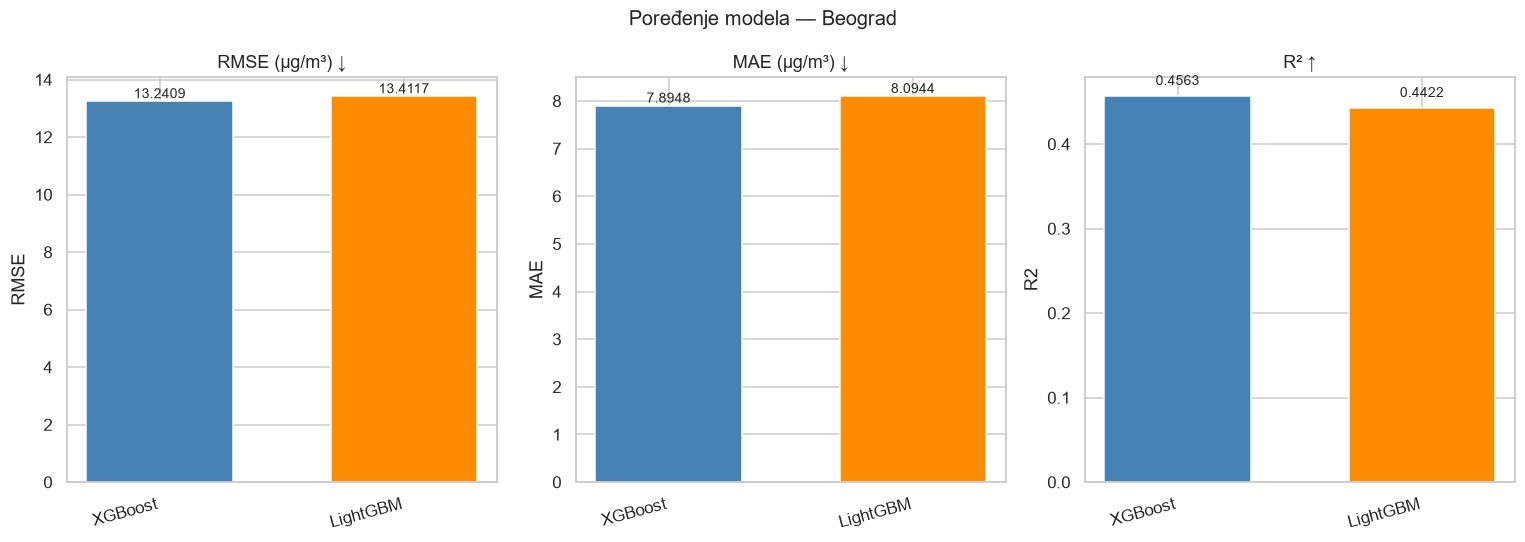

In [5]:
plot_metrics_comparison(results_df, CITY, results_dir=RESULTS)

## 4. Grafik: Stvarne vs. predviđene vrednosti

Vizualizujemo prvih 500 sati test skupa (oko 21 dan) kako bismo videli kako modeli prate stvarne vrednosti kroz vreme. Prikazujemo oba modela jedan ispod drugog radi lakšeg poređenja (sivom bojom su stvarne vrednosti, bojom modela su predikcije).

Na ovom grafiku možemo da primetimo da li model:
- prati opšti trend zagađenja
- kasni u reakciji na nagle skokove
- potcenjuje ili precenjuje ekstremne vrednosti

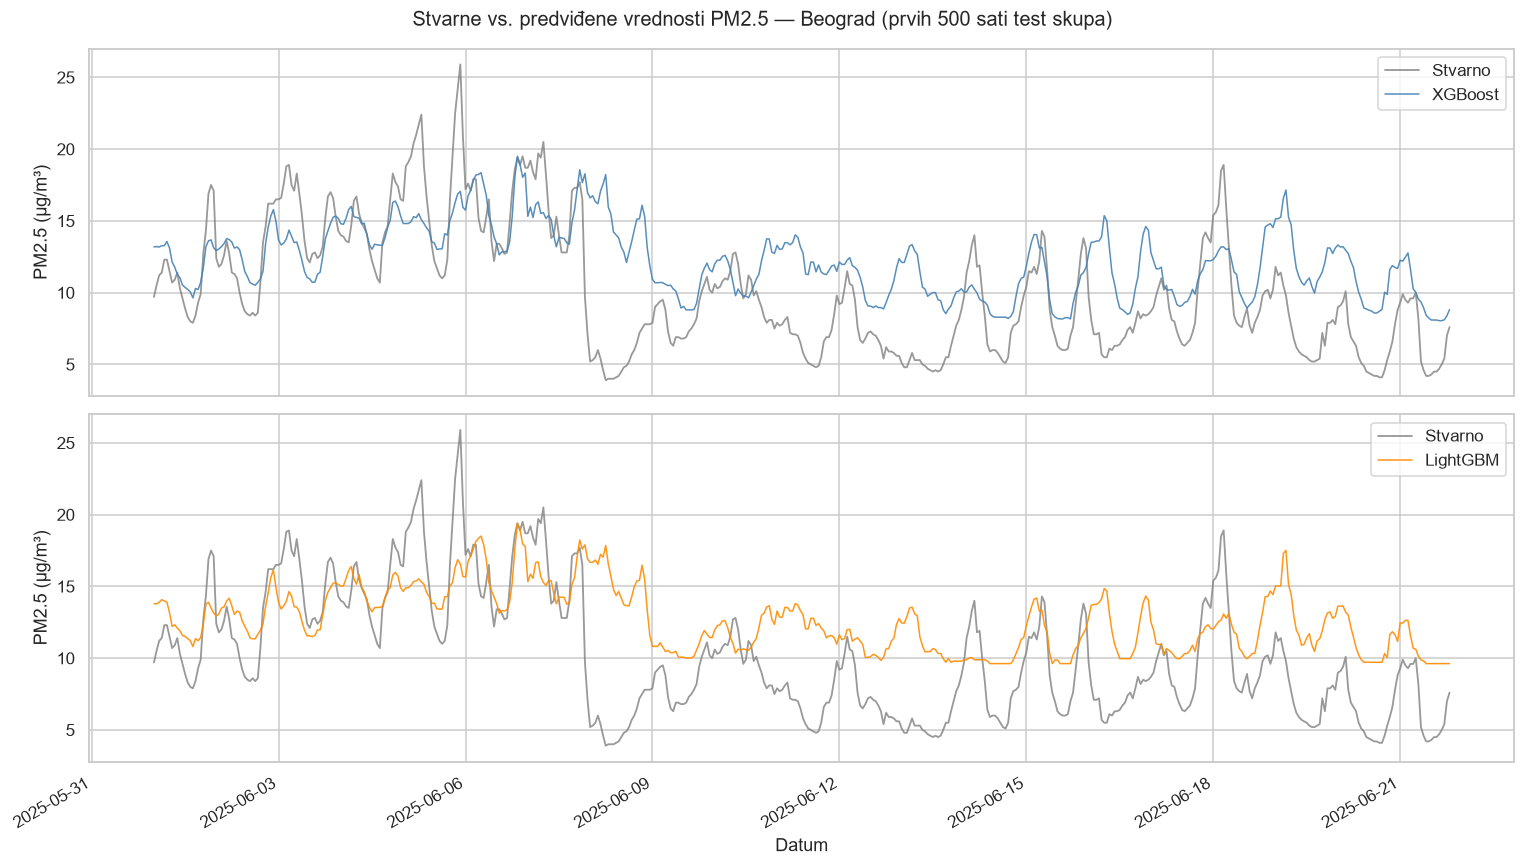

Grafik sačuvan.


In [6]:
dates = test_df['date'].values

plot_timeseries(
    [
        (dates, y_test, y_pred_xgb,  'XGBoost',  'steelblue'),
        (dates, y_test, y_pred_lgbm, 'LightGBM', 'darkorange'),
    ],
    city=CITY, filename=f'timeseries_xgb_lgbm_{CITY}.png', results_dir=RESULTS, n_hours=500,
)

## 5. Scatter plot: Stvarno vs. predviđeno

Scatter plot prikazuje svaki sat test skupa kao jednu tačku. Na x-osi je stvarna vrednost PM2.5, na y-osi predviđena. Crvena isprekidana linija predstavlja **savršenu predikciju** (y = x). Što su tačke bliže toj liniji, model je precizniji.

Važno je pogledati šta se dešava sa **visokim vrednostima** (desni deo grafika). Tu modeli obično imaju najveće greške jer su ekstremni pikovi zagađenja retki u podacima za trening.

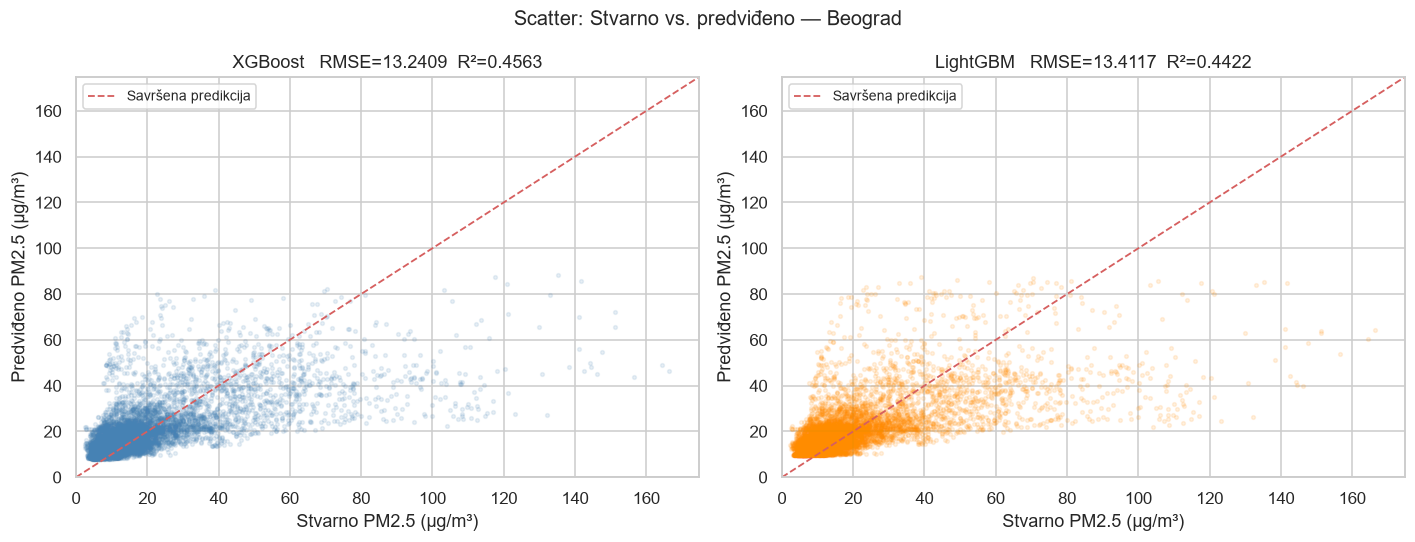

In [7]:
plot_scatter_comparison(
    [
        (y_test, y_pred_xgb,  'XGBoost',  'steelblue',  result_xgb),
        (y_test, y_pred_lgbm, 'LightGBM', 'darkorange', result_lgbm),
    ],
    city=CITY, filename=f'scatter_xgb_lgbm_{CITY}.png', results_dir=RESULTS,
)

## 6. Važnost feature-a (Feature Importance)

Jedna od najvećih prednosti gradient boosting modela nad KNN i LSTM je **interpretabilnost**. Možemo tačno da vidimo koji feature-i su najviše doprineli smanjenju greške tokom treninga.

Svaki put kada model gradi stablo i vrši podelu po nekom feature-u, beleži za koliko je ta podela smanjila grešku. Zbir svih tih doprinosa po feature-u daje meru važnosti.

Ovaj grafik je posebno koristan za razumevanje podataka, ako npr. `pm2_5_lag_24h` (vrednost PM2.5 pre tačno 24 sata) bude visoko rangiran, to potvrđuje da zagađenje ima izraženu **dnevnu periodičnost**.

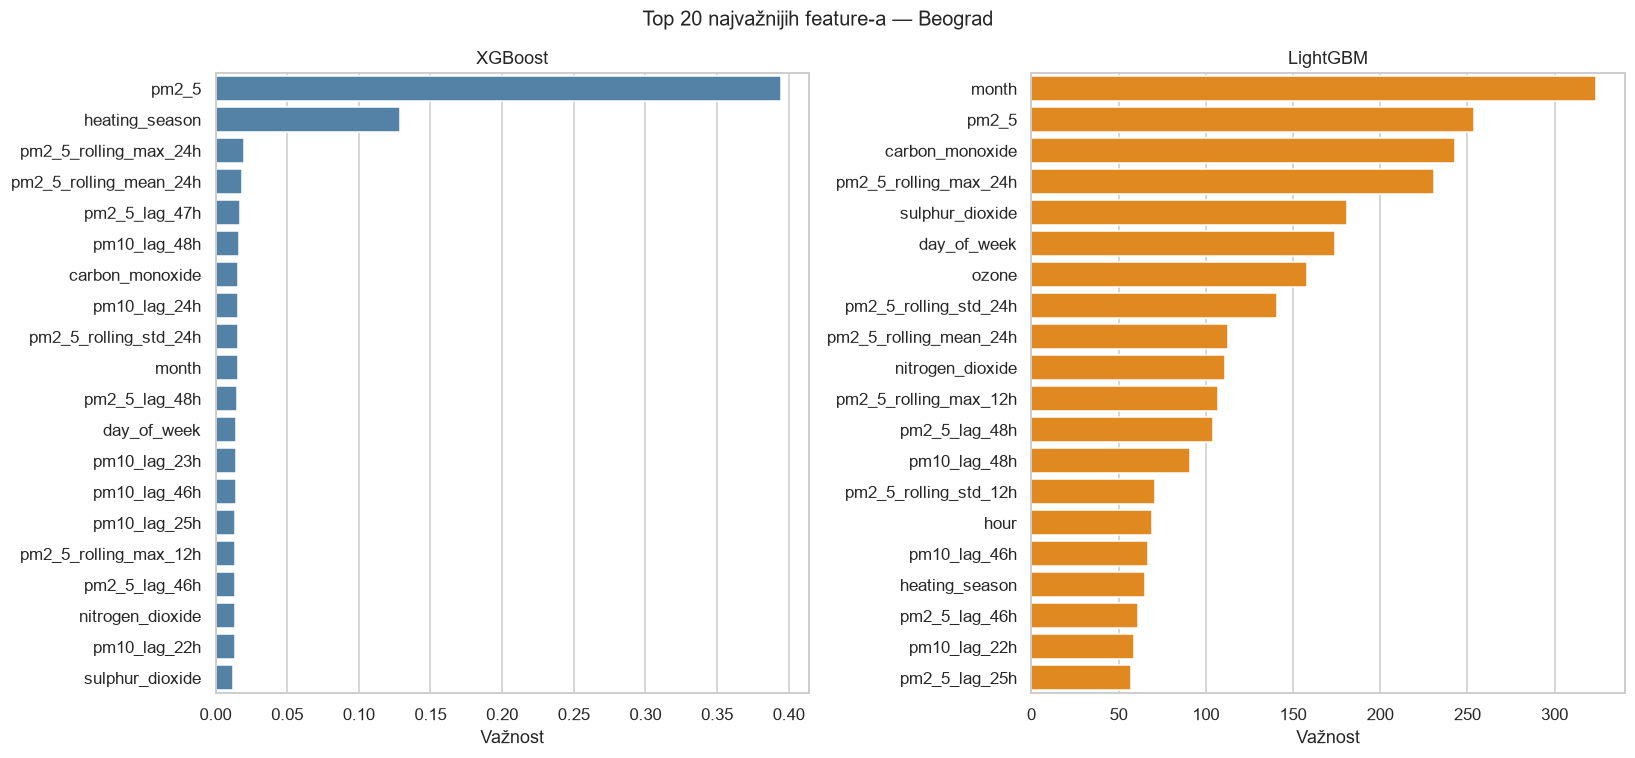

Feature importance grafik sačuvan.


In [8]:
plot_feature_importance(
    [
        (xgb_model,  feature_cols_xgb,  'XGBoost',  'steelblue'),
        (lgbm_model, feature_cols_lgbm, 'LightGBM', 'darkorange'),
    ],
    city=CITY, results_dir=RESULTS, top_n=20,
)

## 7. AQI kategorije: raspodela predikcija

Predviđene numeričke vrednosti PM2.5 mapiramo u **AQI kategorije opasnosti** po zvaničnoj SEPA metodologiji, bez dodatnog treniranja. Ovo je čisto pravilo zasnovano na pragovima:

| Kategorija | PM2.5 (μg/m³) |
|------------|---------------|
| Dobar | ≤ 5 |
| Prihvatljiv | ≤ 15 |
| Umeren | ≤ 50 |
| Zagađen | ≤ 90 |
| Veoma zagađen | ≤ 140 |
| Izuzetno zagađen | > 140 |

Grafik poredi koliko sati u test skupu svaki model predviđa za svaku kategoriju, naspram stvarnih vrednosti. Idealan model bi imao identičnu raspodelu kao kolona "Stvarno".

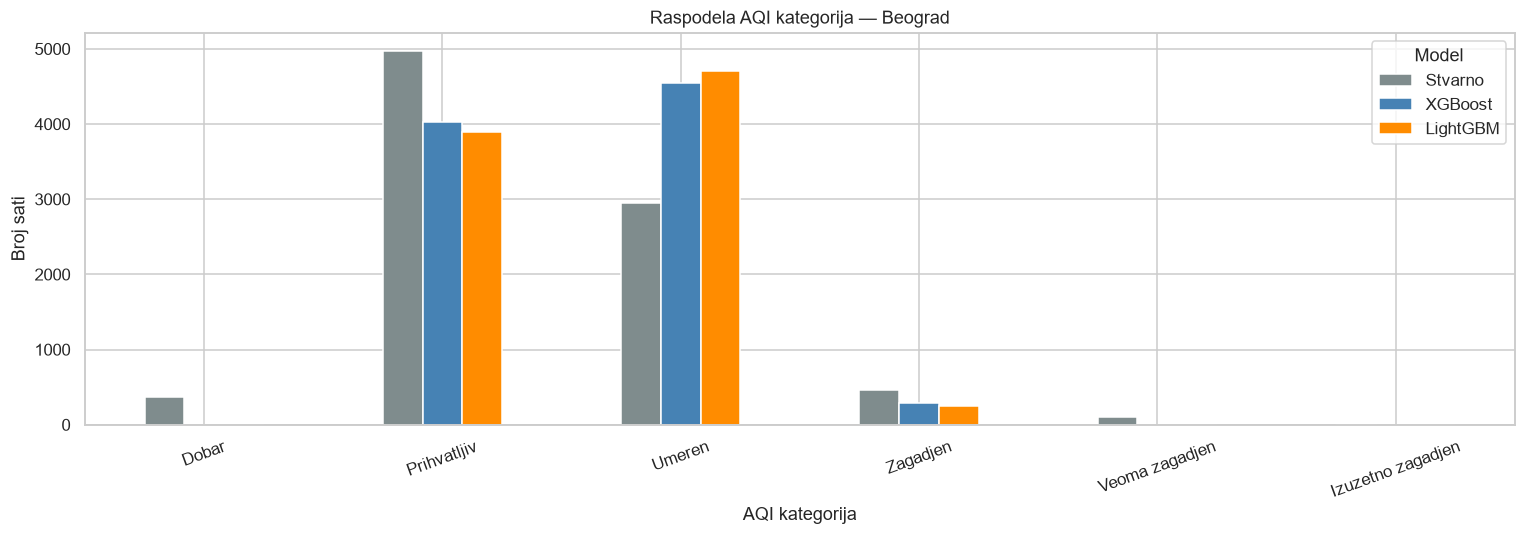

In [9]:
plot_aqi_distribution(
    y_test,
    {'XGBoost': y_pred_xgb, 'LightGBM': y_pred_lgbm},
    city=CITY, filename=f'aqi_distribution_{CITY}.png', results_dir=RESULTS,
)

## 8. Zaključak

**XGBoost** postiže bolji MAE (7.89 vs 8.09 μg/m³), što znači da je u proseku bliži stvarnoj vrednosti. **LightGBM** je nešto slabiji po svim metrikama na ovom skupu podataka, ali njegova ključna prednost je brzina treninga; leaf-wise rast stabla omogućava da se trenira i do nekoliko puta brže, što je posebno važno kada treba obraditi veću količinu informacija.

Feature importance grafici potvrđuju da su **lag feature-i PM2.5 za prethodnih 24 sata** najvažniji prediktori što je fizički smisleno, jer zagađenje ima izraženu dnevnu periodičnost. Rolling statistike (klizni prosek i maksimum) takođe zauzimaju visoke pozicije, što potvrđuje vrednost feature engineeringa koji je urađen u `data_prep.py`.

Oba modela konzistentno prepoznaju AQI kategorije: raspodela predviđenih kategorija bliska je stvarnoj raspodeli što znači da su modeli upotrebljivi za praktičnu primenu u sistemu ranog upozoravanja.